In [ ]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()


## HLT 를 먼저 통과 한 이벤트 , hlthps tau 0개 이상인 이벤트만 -> 남은 이벤트 중에서 gen match -> genmatch 가 된 hlthps 의 이벤트를 남겨 놓음  



def get_info (sample):
    file = uproot.open(sample)
    events = file["Events"]
    runs = file["Runs"]
    keys = events.keys()

    # 변수 불러오기 

    tau_pt = events["hltHpsPFTau_pt"].array()
    tau_eta = events["hltHpsPFTau_eta"].array()
    tau_phi = events["hltHpsPFTau_phi"].array()
    tau_mass = events["hltHpsPFTau_mass"].array()


    genvis_tau_pt = events["GenVisTau_pt"].array()
    genvis_tau_eta = events["GenVisTau_eta"].array()
    genvis_tau_phi = events["GenVisTau_phi"].array()
    genvis_tau_mass = events["GenVisTau_mass"].array()
    #print(len(genvis_tau_pt),"gen vis tau total events")

    # 필터 설정

    ## trigger filter ( returns_num_den 에서 사용됨  )
    tau_trigger_filter = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array()

    ## hlthpstau 1개 이상 필터 

    tau_num = ak.num(tau_pt)
    no_tau = (tau_num == 0) # [ False, True, False, ... ] 2000개 
    has_tau = ~no_tau
    hlt_has_tau_filter = (has_tau) ## hlthps tau 1개 이상 있는 이벤트만 선택

    tau_triggerd_list= (hlt_has_tau_filter==True)  
    
    ## final selected variables ( hlthps 있는 이벤트만 남김 )
    final_tau_pt = tau_pt[tau_triggerd_list]
    final_tau_eta = tau_eta[tau_triggerd_list]
    final_tau_phi = tau_phi[tau_triggerd_list]
    final_tau_mass = tau_mass[tau_triggerd_list]

    final_genvis_tau_pt = genvis_tau_pt[tau_triggerd_list]
    final_genvis_tau_eta = genvis_tau_eta[tau_triggerd_list]
    final_genvis_tau_phi = genvis_tau_phi[tau_triggerd_list]
    final_genvis_tau_mass = genvis_tau_mass[tau_triggerd_list]

    tau_trigger_filtered = tau_trigger_filter[tau_triggerd_list]




    total_events = len(tau_pt)
    print("total events:", total_events,"->","after trigger filter:",ak.sum(has_tau),"->","after reconstructed hlthps ,events remain",len(final_tau_pt))
    return events,final_tau_pt, final_tau_eta, final_tau_phi, final_tau_mass, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, final_genvis_tau_mass ,genvis_tau_pt , genvis_tau_eta , genvis_tau_phi ,tau_trigger_filtered


def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)

def gen_match(tau_pt, tau_eta, tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi, deltaR_threshold=0.3,delta_pt_threshold=10):
    matched = [] ## gen 이벤트 인덱스 안에 들어있는 각 gen 입자의 매칭 여부 리스트 [[ True(event1 1 particle), False(event1 2 particle), ... ](event1), [ False, False, ... ](event2), ... ]
    events_flag = [] ## gen match 된 이벤트인지 아닌지 gen 이벤트의 bool 리스트 [ True(event1), False(event2), ... ]
    reco_matched = [] ## reco 이벤트 인덱스 안에 들어있는 각 reco 입자의 매칭 여부 리스트
    leading_matched = []
    subleading_matched = []
    both_matched = []

    for i in range(len(genvis_tau_pt)):
        # 1. 정렬
        reco_indices = ak.argsort(tau_pt[i], ascending=False)
        t_pt, t_eta, t_phi = tau_pt[i][reco_indices], tau_eta[i][reco_indices], tau_phi[i][reco_indices]
        
        # 2. 이번 이벤트의 상태 초기화 (이벤트 루프 시작할 때마다 초기화해야 함)
        reco_match_flag = [False] * len(t_pt) 
        match_flags = []
        has_genmatch = False
        leading_match = False
        subleading_match = False

        # Gen 입자 루프
        for j in range(len(genvis_tau_pt[i])):
            g_pt, g_eta, g_phi = genvis_tau_pt[i][j], genvis_tau_eta[i][j], genvis_tau_phi[i][j]
            is_matched = False
            
            # 3. Leading Reco Tau(인덱스 0)와 매칭 시도
            if len(t_pt) > 0:
                # k 루프 대신 인덱스 0 사용 (Leading)
                if abs(t_eta[0]) <= 2.1:
                    dR = deltaR(t_eta[0], t_phi[0], g_eta, g_phi)
                    dpt = abs(t_pt[0] - g_pt)
                    
                    if dR < deltaR_threshold and dpt < delta_pt_threshold:
                        is_matched = True
                        has_genmatch = True
                        reco_match_flag[0] = True # Leading 매칭 표시
                        leading_match = True      # 플래그 업데이트
                        # 만약 여기서 j(gen) 루프를 탈출하고 싶다면 break
            
            match_flags.append(is_matched)
        if has_genmatch:
            events_flag.append(True) # 이벤트 자체가 매칭된 이벤트인지 저장 
        else:
            events_flag.append(False)
        matched.append(np.array(match_flags)) ## 이벤트 당 match_flags(입자가 매칭됐는지를 리스트형태로 저장 )
        reco_matched.append(np.array(reco_match_flag))


    return both_matched,leading_matched , subleading_matched , matched ,events_flag , reco_matched


#sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/step2_fullstack_180.root"
#events_180,final_tau_pt_180, final_tau_eta_180, final_tau_phi_180, final_tau_mass_180, final_genvis_tau_pt_180, final_genvis_tau_eta_180, final_genvis_tau_phi_180, final_genvis_tau_mass_180 ,genvis_tau_pt_180 , genvis_tau_eta_180, genvis_tau_phi_180,tau_trigger_filter_180= get_info(sample)
#both_matched_180, leading_only_matched_180 , subleading_only_matched_180,gen_matched_180,events_flag_180 = gen_match(final_tau_pt_180, final_tau_eta_180, final_tau_phi_180, final_genvis_tau_pt_180, final_genvis_tau_eta_180, final_genvis_tau_phi_180)
def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)

sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
events_150,final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_tau_mass_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, final_genvis_tau_mass_150,genvis_tau_pt_150 , genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150 = get_info(sample)
both_matched_150, leading_only_matched_150 , subleading_only_matched_150,gen_matched_150,events_flag_150 , reco_matched_150= gen_match(final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150)




total events: 20000 -> after trigger filter: 12722 -> after reconstructed hlthps ,events remain 12722


In [7]:
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()



hltHpsPFTau_decayMode = events["hltHpsPFTau_decayMode"].array()
print(hltHpsPFTau_decayMode)

[[10, 10, 2, 0, 1, 1, 1, 1, 2, 1, 2, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ...]


In [ ]:

import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt

## 리딩 서브리딩 아무거나 매칭 된 경우 

    
def returns_num_den(gen_matched, events_flag, final_tau_pt, final_tau_eta, final_tau_phi, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi, tau_trigger_filter):
    
    
    events_flag_den = events_flag
    # Denominator 데이터 준비
    match_genvistau_pt_raw = final_genvis_tau_pt[events_flag_den]
    match_genvistau_eta_raw = final_genvis_tau_eta[events_flag_den]
    match_genvistau_phi_raw = final_genvis_tau_phi[events_flag_den]
    print(len(match_genvistau_pt_raw),"gen after event flag")
    # 각 이벤트에서 가장 큰 pT를 가진 인덱스 찾기
    max_indices = ak.argmax(match_genvistau_pt_raw, axis=1, keepdims=True)
    
    # 분모 (Leading Gen Tau 추출)
    den_pt = ak.flatten(match_genvistau_pt_raw[max_indices])
    den_eta = ak.flatten(match_genvistau_eta_raw[max_indices])
    den_phi = ak.flatten(match_genvistau_phi_raw[max_indices])
    print(len(den_pt),"gen after largest pt den")

    
    # Numerator 데이터 준비 (Trigger 통과 여부 확인)
    match_trigger_filter = events_flag & tau_trigger_filter 
    triggered_genvistau_pt_raw = final_genvis_tau_pt[match_trigger_filter]
    triggered_genvistau_eta_raw = final_genvis_tau_eta[match_trigger_filter]
    triggered_genvistau_phi_raw = final_genvis_tau_phi[match_trigger_filter]
    print(len(triggered_genvistau_pt_raw),"gen after matching")
    # 분자 (Trigger 통과한 이벤트 중 Leading Gen Tau 추출)
    max_indices_num = ak.argmax(triggered_genvistau_pt_raw, axis=1, keepdims=True)
    
    num_pt = ak.flatten(triggered_genvistau_pt_raw[max_indices_num])
    num_eta = ak.flatten(triggered_genvistau_eta_raw[max_indices_num])
    num_phi = ak.flatten(triggered_genvistau_phi_raw[max_indices_num])
    print(len(num_pt),"gen largest after matching")
    # Reco 정보 (비교용)
    reco_tau_pt = final_tau_pt[match_trigger_filter]
    reco_tau_eta = final_tau_eta[match_trigger_filter]

    return num_pt, den_pt, num_eta, den_eta, num_phi, den_phi, reco_tau_pt, reco_tau_eta

def returns_reco_num_den (gen_matched, events_flag, final_tau_pt, final_tau_eta, final_tau_phi, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi,tau_trigger_filter):
    ### numerator 
    recotau_pt_den = final_tau_pt[events_flag]
    recotau_eta_den = final_tau_eta[events_flag]
    recotau_phi_den = final_tau_phi[events_flag]
    print(len(final_tau_pt),"final tau pt length")
    max_values = np.max(recotau_pt_den, axis=1)
    print(len(max_values),"max values length")
    max_indices = np.argmax(recotau_pt_den, axis=1)
    max_eta_list = []
    max_phi_list = []
    for i in range(len(max_values)):
        max_eta_list.append(recotau_eta_den[i][max_indices[i]])
        max_phi_list.append(recotau_phi_den[i][max_indices[i]])

    ### denominator
    match_trigger_filter = events_flag & tau_trigger_filter # using_eta

    recotau_pt_num = final_tau_pt[match_trigger_filter]
    recotau_eta_num = final_tau_eta[match_trigger_filter]
    recotau_phi_num = final_tau_phi[match_trigger_filter]

    max_values_num = np.max(recotau_pt_num, axis=1)
    max_indices_num = np.argmax(recotau_pt_num, axis=1)
    max_eta_list_num = []
    max_phi_list_num = []
    for i in range(len(max_values_num)):
        max_eta_list_num.append(recotau_eta_num[i][max_indices_num[i]])
        max_phi_list_num.append(recotau_phi_num[i][max_indices_num[i]])
    print(len(max_values_num),"max values num length")
    ############
    ############
    num_pt = max_values_num
    num_eta = max_eta_list_num
    num_phi = max_phi_list_num
    ## denominator ( 모든 genvistau 정보 )
    den_pt = max_values
    den_eta = max_eta_list
    den_phi = max_phi_list

    return num_pt, den_pt, num_eta, den_eta, num_phi, den_phi  


num_pt_150 , den_pt_150, num_eta_150, den_eta_150, num_phi_150, den_phi_150 = returns_reco_num_den (gen_matched_150, events_flag_150, final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, genvis_tau_pt_150, genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150)
num_pt_gen_150 , den_pt_gen_150, num_eta_gen_150, den_eta_gen_150, num_phi_gen_150, den_phi_gen_150 , reco_tau_pt_150 , reco_tau_eta_150= returns_num_den (gen_matched_150, events_flag_150, final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, genvis_tau_pt_150, genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150)
#pt 150 filter




####
#### reco plot 
####
####


##pt 

bins_0 = np.arange(0, 130, 10)
bins_1 = np.arange(131, 180, 5)
bins_2 = np.arange(181, 300, 20)
bins_3 = np.arange(301, 601, 100)
bins = np.concatenate((bins_0, bins_1, bins_2, bins_3))


print(len(den_pt_150),"before flatten")
num_pt_150 = ak.flatten(num_pt_150,axis=None)
den_pt_150 = ak.flatten(den_pt_150,axis=None)
print(len(den_pt_150),"after flatten")
num_pt_150 = num_pt_150.to_numpy()
den_pt_150 = den_pt_150.to_numpy()

counts_num_150, edges_pt = np.histogram(num_pt_150, bins=bins)
counts_den_150, _ = np.histogram(den_pt_150, bins=bins)

ratio_150 = np.divide(counts_num_150, counts_den_150, 
                      out=np.zeros_like(counts_num_150, dtype=float), 
                      where=(counts_den_150 != 0))
ratio_err_150 = np.zeros_like(ratio_150)
nonzero_150 = counts_den_150 > 0
ratio_err_150[nonzero_150] = np.sqrt(ratio_150[nonzero_150] * (1.0 - ratio_150[nonzero_150]) / counts_den_150[nonzero_150])

print(len(num_pt_150)/len(den_pt_150) *100 ,"efficiency of reco tau(%)")

num_over_150 = num_pt_150 >= 150
den_over_150 = den_pt_150 >= 150

## eta

bins = np.arange(-3.0, 3.0, 0.1)

num_eta_150 = ak.flatten(num_eta_150,axis=None)
den_eta_150 = ak.flatten(den_eta_150,axis=None)
num_eta_150 = num_eta_150.to_numpy()
den_eta_150 = den_eta_150.to_numpy()

num_eta_150 = num_eta_150[num_over_150]
den_eta_150 = den_eta_150[den_over_150]

counts_num_150, edges_eta = np.histogram(num_eta_150, bins=bins)
counts_den_150, _ = np.histogram(den_eta_150, bins=bins)
ratio_eta_150 = np.divide(counts_num_150, counts_den_150, 
                      out=np.zeros_like(counts_num_150, dtype=float), 
                      where=(counts_den_150 != 0))
ratio_err_eta_150 = np.zeros_like(ratio_eta_150)
nonzero_eta_150 = counts_den_150 > 0
ratio_err_eta_150[nonzero_eta_150] = np.sqrt(ratio_eta_150[nonzero_eta_150] * (1.0 - ratio_eta_150[nonzero_eta_150]) / counts_den_150[nonzero_eta_150])



## phi 

bins = np.arange(-3.2, 3.2, 0.1)
num_phi_150 = ak.flatten(num_phi_150,axis=None)
den_phi_150 = ak.flatten(den_phi_150,axis=None)
num_phi_150 = num_phi_150.to_numpy()
den_phi_150 = den_phi_150.to_numpy()

num_phi_150 = num_phi_150[num_over_150]
den_phi_150 = den_phi_150[den_over_150]

counts_num_150, edges_phi = np.histogram(num_phi_150, bins=bins)
counts_den_150, _ = np.histogram(den_phi_150, bins=bins)
ratio_phi_150 = np.divide(counts_num_150, counts_den_150, 
                      out=np.zeros_like(counts_num_150, dtype=float), 
                      where=(counts_den_150 != 0))
ratio_err_phi_150 = np.zeros_like(ratio_phi_150)
nonzero_phi_150 = counts_den_150 > 0
ratio_err_phi_150[nonzero_phi_150] = np.sqrt(ratio_phi_150[nonzero_phi_150] * (1.0 - ratio_phi_150[nonzero_phi_150]) / counts_den_150[nonzero_phi_150])





####
####
####Gen plot ########################################################
####

##pt

bins_0 = np.arange(0, 130, 10)
bins_1 = np.arange(131, 180, 5)
bins_2 = np.arange(181, 300, 20)
bins_3 = np.arange(301, 601, 100)
bins = np.concatenate((bins_0, bins_1, bins_2, bins_3))

print(num_pt_gen_150)
print(len(num_pt_gen_150))
num_pt_gen_150 = ak.flatten(num_pt_gen_150,axis=None)
den_pt_gen_150 = ak.flatten(den_pt_gen_150,axis=None)
num_pt_gen_150 = num_pt_gen_150.to_numpy()
den_pt_gen_150 = den_pt_gen_150.to_numpy()

counts_num_gen_150, edges_pt = np.histogram(num_pt_gen_150, bins=bins)
counts_den_gen_150, _ = np.histogram(den_pt_gen_150, bins=bins)

ratio_gen_150 = np.divide(counts_num_gen_150, counts_den_gen_150, 
                      out=np.zeros_like(counts_num_gen_150, dtype=float), 
                      where=(counts_den_gen_150 != 0))
ratio_err_gen_150 = np.zeros_like(ratio_gen_150)
nonzero_gen_150 = counts_den_gen_150 > 0
ratio_err_gen_150[nonzero_gen_150] = np.sqrt(ratio_gen_150[nonzero_gen_150] * (1.0 - ratio_gen_150[nonzero_gen_150]) / counts_den_gen_150[nonzero_gen_150])

gen_num_over_150 = num_pt_gen_150 >= 150
gen_den_over_150 = den_pt_gen_150 >= 150



## eta 


bins = np.arange(-3.0, 3.0, 0.1)
num_eta_gen_150 = ak.flatten(num_eta_gen_150,axis=None)
den_eta_gen_150 = ak.flatten(den_eta_gen_150,axis=None)
num_eta_gen_150 = num_eta_gen_150.to_numpy()
den_eta_gen_150 = den_eta_gen_150.to_numpy()

num_eta_gen_150 = num_eta_gen_150[gen_num_over_150]
den_eta_gen_150 = den_eta_gen_150[gen_den_over_150]

counts_num_gen_150, edges_eta = np.histogram(num_eta_gen_150, bins=bins)
counts_den_gen_150, _ = np.histogram(den_eta_gen_150, bins=bins)
ratio_gen_eta_150 = np.divide(counts_num_gen_150, counts_den_gen_150, 
                      out=np.zeros_like(counts_num_gen_150, dtype=float), 
                      where=(counts_den_gen_150 != 0))
ratio_err_gen_eta_150 = np.zeros_like(ratio_gen_eta_150)
nonzero_eta_gen_150 = counts_den_gen_150 > 0
ratio_err_gen_eta_150[nonzero_eta_gen_150] = np.sqrt(ratio_gen_eta_150[nonzero_eta_gen_150] * (1.0 - ratio_gen_eta_150[nonzero_eta_gen_150]) / counts_den_gen_150[nonzero_eta_gen_150])


## phi 

bins = np.arange(-3.2, 3.2, 0.1)
num_phi_gen_150 = ak.flatten(num_phi_gen_150,axis=None)
den_phi_gen_150 = ak.flatten(den_phi_gen_150,axis=None)
num_phi_gen_150 = num_phi_gen_150.to_numpy()
den_phi_gen_150 = den_phi_gen_150.to_numpy()

num_phi_gen_150 = num_phi_gen_150[gen_num_over_150]
den_phi_gen_150 = den_phi_gen_150[gen_den_over_150]

counts_num_gen_150, edges_phi = np.histogram(num_phi_gen_150, bins=bins)
counts_den_gen_150, _ = np.histogram(den_phi_gen_150, bins=bins)
ratio_gen_phi_150 = np.divide(counts_num_gen_150, counts_den_gen_150, 
                      out=np.zeros_like(counts_num_gen_150, dtype=float), 
                      where=(counts_den_gen_150 != 0))
ratio_err_gen_phi_150 = np.zeros_like(ratio_gen_phi_150)
nonzero_phi_gen_150 = counts_den_gen_150 > 0
ratio_err_gen_phi_150[nonzero_phi_gen_150] = np.sqrt(ratio_gen_phi_150[nonzero_phi_gen_150] * (1.0 - ratio_gen_phi_150[nonzero_phi_gen_150]) / counts_den_gen_150[nonzero_phi_gen_150])


###################plotter####################
############################################################
############################################################

# plot with error bars
bin_centers = (edges_pt[:-1] + edges_pt[1:]) / 2.0
half_widths = (edges_pt[1:] - edges_pt[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Reco 데이터
ax.errorbar(bin_centers, ratio_150, xerr=half_widths, yerr=ratio_err_150, 
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8,
            label=r'Reco $\tau$') # r을 붙이고 &와 \tau를 확인하세요.

# 2. Gen 데이터
ax.errorbar(bin_centers, ratio_gen_150, xerr=half_widths, yerr=ratio_err_gen_150, 
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5,
            label=r'Gen $\tau$')

# 축 및 레이블 설정
ax.set_xlabel(r'DM 10 Tau $p_T$ [GeV]', fontsize=18)
ax.set_ylabel('Efficiency', fontsize=18)
ax.set_xlim(edges_pt[0], edges_pt[-1])
ax.set_ylim(0, 1.1)

# 트리거 임계값 표시
ax.axvline(x=150, color='gray', linestyle='--', linewidth=2, label='Threshold (150 GeV)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
# 레전드 (범례) 설정
ax.legend(loc='lower right', fontsize=14, frameon=True)

# 그리드 및 스타일 마무리
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)

# CMS 정보 표시
hep.cms.text("Simulation Preliminary", loc=0, ax=ax) # loc=0은 상단 왼쪽
ax.text(0.7, 1.06, r"$Z'(500GeV) \to \tau \tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

print(num_pt_150)
print(den_pt_150)
overthreshold_num_150 = num_pt_150[num_pt_150 >= 150]
overthreshold_den_150 = den_pt_150[den_pt_150 >= 150]
print("reco tau efficiency over 150GeV:", len(overthreshold_num_150)/len(overthreshold_den_150) *100 ,"%")



### eta

# plot with error bars
bin_centers = (edges_eta[:-1] + edges_eta[1:]) / 2.0
half_widths = (edges_eta[1:] - edges_eta[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Reco 데이터
ax.errorbar(bin_centers, ratio_eta_150, xerr=half_widths, yerr=ratio_err_eta_150, 
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8,
            label=r'Reco $\tau$') # r을 붙이고 &와 \tau를 확인하세요.

# 2. Gen 데이터
ax.errorbar(bin_centers, ratio_gen_eta_150, xerr=half_widths, yerr=ratio_err_gen_eta_150, 
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5,
            label=r'Gen $\tau$')

# 축 및 레이블 설정
ax.set_xlabel(r'DM 10 Tau$\eta$', fontsize=18)
ax.set_ylabel('Efficiency', fontsize=18)
ax.set_xlim(edges_eta[0], edges_eta[-1])
ax.set_ylim(0, 1.1)

# 트리거 임계값 표시
ax.axvline(x=150, color='gray', linestyle='--', linewidth=2, label='Threshold (150 GeV)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
# 레전드 (범례) 설정
ax.legend(loc='lower right', fontsize=14, frameon=True)

# 그리드 및 스타일 마무리
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)

# CMS 정보 표시
hep.cms.text("Simulation Preliminary", loc=0, ax=ax) # loc=0은 상단 왼쪽
ax.text(0.7, 1.06, r"$Z'(500GeV) \to \tau \tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()



### phi 

# plot with error bars
bin_centers = (edges_phi[:-1] + edges_phi[1:]) / 2.0
half_widths = (edges_phi[1:] - edges_phi[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

# 1. Reco 데이터
ax.errorbar(bin_centers, ratio_phi_150, xerr=half_widths, yerr=ratio_err_phi_150, 
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8,
            label=r'Reco $\tau$') # r을 붙이고 &와 \tau를 확인하세요.

# 2. Gen 데이터
ax.errorbar(bin_centers, ratio_gen_phi_150, xerr=half_widths, yerr=ratio_err_gen_phi_150, 
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5,
            label=r'Gen $\tau$')

# 축 및 레이블 설정
ax.set_xlabel(r'DM 10 Tau $\phi$', fontsize=18)
ax.set_ylabel('Efficiency', fontsize=18)
ax.set_xlim(edges_phi[0], edges_phi[-1])
ax.set_ylim(0, 1.1)

# 트리거 임계값 표시
ax.axvline(x=150, color='gray', linestyle='--', linewidth=2, label='Threshold (150 GeV)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
# 레전드 (범례) 설정
ax.legend(loc='lower right', fontsize=14, frameon=True)

# 그리드 및 스타일 마무리
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)

# CMS 정보 표시
hep.cms.text("Simulation Preliminary", loc=0, ax=ax) # loc=0은 상단 왼쪽
ax.text(0.7, 1.06, r"$Z'(500GeV) \to \tau \tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()




NameError: name 'gen_matched_150' is not defined

In [29]:
print(len(num_pt_150))
print(num_pt_150)
print(len(num_pt_gen_150))
print(num_pt_gen_150)

print(len(den_pt_150))
print(len(den_pt_gen_150))


2257
[221.10184 160.84053 246.6816  ... 192.1634  238.30392 231.185  ]
2257
[222.  166.5 250.5 ... 189.5 241.5 233.5]
4758
4758


In [27]:
print("Reco Denominator counts per bin:", counts_den_150)
print("Gen Denominator counts per bin:", counts_den_gen_150)

Reco Denominator counts per bin: [18 37 26 42 36 41 30 37 47 31 30 32 38 36 38 29 40 33 34 30 36 33 45 39
 36 36 36 42 47 30 42 34 38 50 31 34 42 44 39 40 45 39 32 33 36 29 30 28
 29 36 36 40 31 39 32 48 34 36 44 35 29 29 38]
Gen Denominator counts per bin: [21 41 34 46 35 43 41 38 48 39 33 33 40 40 43 34 45 38 37 35 42 34 51 38
 36 43 38 47 50 36 40 38 41 48 36 39 45 44 44 46 45 46 35 36 38 34 29 31
 37 39 42 41 35 38 32 50 38 39 49 36 31 30 38]


In [ ]:
print(ratio_err_150)
print(ratio_err_gen_150)


NameError: name 'ratio_err_150' is not defined

In [37]:
print(ratio_150)
print(counts_den_150 )
print(ratio_gen_150)
print(counts_den_gen_150 )

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.18934911 0.98148148
 0.97546012 0.98709677 0.98816568 0.98630137 1.         0.99196787
 0.99452055 1.         0.99099099 1.         1.         1.
 1.        ]
[18 37 26 42 36 41 30 37 47 31 30 32 38 36 38 29 40 33 34 30 36 33 45 39
 36 36 36 42 47 30 42 34 38 50 31 34 42 44 39 40 45 39 32 33 36 29 30 28
 29 36 36 40 31 39 32 48 34 36 44 35 29 29 38]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.04294479 0.29268293 0.66111111
 0.83333333 0.85795455 0.89349112 0.92307692 0.89171975 0.92045455
 0.93301435 0.94656489 0.94871795 0.97916667 0.96969697 0.97222222
 0.83333333]
[21 41 34 46 35 43 41 38 48 39 33 33 40 40 43 34 45 38 37 35 42 34 51 38
 36 43 38 47 50 36 40 38 41 48 36 39 45 44 44 46 45 46 35 36 38 34 29 31
 37 3

debugging


In [ ]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()


## HLT 를 먼저 통과 한 이벤트 , hlthps tau 0개 이상인 이벤트만 -> 남은 이벤트 중에서 gen match -> genmatch 가 된 hlthps 의 이벤트를 남겨 놓음  



def get_info (sample):
    file = uproot.open(sample)
    events = file["Events"]
    runs = file["Runs"]
    keys = events.keys()

    # 변수 불러오기 

    tau_pt = events["hltHpsPFTau_pt"].array()
    tau_eta = events["hltHpsPFTau_eta"].array()
    tau_phi = events["hltHpsPFTau_phi"].array()
    tau_mass = events["hltHpsPFTau_mass"].array()

    hltHpsPFTau_decayMode = events["hltHpsPFTau_decayMode"].array()
    
    genvis_tau_pt = events["GenVisTau_pt"].array()
    genvis_tau_eta = events["GenVisTau_eta"].array()
    genvis_tau_phi = events["GenVisTau_phi"].array()
    genvis_tau_mass = events["GenVisTau_mass"].array()
    
    #print(len(genvis_tau_pt),"gen vis tau total events")

    # 필터 설정
    gen_obj_mask = (genvis_tau_pt > 130) & (abs(genvis_tau_eta) < 2.1)
    genvis_tau_pt   = genvis_tau_pt[gen_obj_mask]
    genvis_tau_eta  = genvis_tau_eta[gen_obj_mask]
    genvis_tau_phi  = genvis_tau_phi[gen_obj_mask]

    reco_obj_mask = (tau_pt > 130) & (abs(tau_eta) < 2.1)
    tau_pt   = tau_pt[reco_obj_mask]
    tau_eta  = tau_eta[reco_obj_mask]
    tau_phi  = tau_phi[reco_obj_mask]
    ## trigger filter ( returns_num_den 에서 사용됨  )
    tau_trigger_filter = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array()

    ## hlthpstau 1개 이상 필터 

    tau_num = ak.num(tau_pt)
    no_tau = (tau_num == 0) # [ False, True, False, ... ] 2000개 
    has_tau = ~no_tau
    hlt_has_tau_filter = (has_tau) ## hlthps tau 1개 이상 있는 이벤트만 선택

    tau_triggerd_list = hlt_has_tau_filter 

    ## final selected variables ( hlthps 있는 이벤트만 남김 )
    final_tau_pt = tau_pt[tau_triggerd_list]
    final_tau_eta = tau_eta[tau_triggerd_list]
    final_tau_phi = tau_phi[tau_triggerd_list]
    final_tau_mass = tau_mass[tau_triggerd_list]

    final_genvis_tau_pt = genvis_tau_pt[tau_triggerd_list]
    final_genvis_tau_eta = genvis_tau_eta[tau_triggerd_list]
    final_genvis_tau_phi = genvis_tau_phi[tau_triggerd_list]
    final_genvis_tau_mass = genvis_tau_mass[tau_triggerd_list]

    tau_trigger_filtered = tau_trigger_filter[tau_triggerd_list]

    hltHpsPFTau_decayMode = hltHpsPFTau_decayMode[tau_triggerd_list]


    total_events = len(tau_pt)
    print("total events:", total_events,"->","after trigger filter:",ak.sum(has_tau),"->","after reconstructed hlthps ,events remain",len(final_tau_pt))
    return events,final_tau_pt, final_tau_eta, final_tau_phi, final_tau_mass, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, final_genvis_tau_mass ,genvis_tau_pt , genvis_tau_eta , genvis_tau_phi ,tau_trigger_filtered , hltHpsPFTau_decayMode


def gen_match(tau_pt, tau_eta, tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi, deltaR_threshold=0.1):
    """
    Leading reco tau 기준으로 gen tau와 매칭.
    후보가 여럿이면 deltaR이 가장 작은 gen tau 선택.
    반환: events_flag (bool list), matched_gen_pt/eta/phi (매칭된 gen tau의 운동학 정보)
    """
    events_flag      = []
    matched_gen_pt   = []
    matched_gen_eta  = []
    matched_gen_phi  = []

    for i in range(len(tau_pt)):

        # Leading reco tau 찾기 (pT 기준 정렬 후 index 0)
        if len(tau_pt[i]) == 0:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)
            continue

        reco_indices  = ak.argsort(tau_pt[i], ascending=False)
        lead_pt   = tau_pt[i][reco_indices[0]]
        lead_eta  = tau_eta[i][reco_indices[0]]
        lead_phi  = tau_phi[i][reco_indices[0]]

        # eta 2.1 컷
        if abs(lead_eta) > 2.1:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)
            continue

        # Leading reco tau와 모든 gen tau 매칭 시도
        best_dR   = 999.
        best_gen_idx = -1

        for j in range(len(genvis_tau_pt[i])):
            g_pt  = genvis_tau_pt[i][j]
            g_eta = genvis_tau_eta[i][j]
            g_phi = genvis_tau_phi[i][j]

            dR  = deltaR(lead_eta, lead_phi, g_eta, g_phi)
            dpt = abs(float(lead_pt) - float(g_pt))

            if dR < deltaR_threshold : #and dpt < delta_pt_threshold:
                if dR < best_dR:          # deltaR 가장 작은 gen 선택
                    best_dR      = dR
                    best_gen_idx = j

        if best_gen_idx >= 0:
            events_flag.append(True)
            matched_gen_pt.append(float(genvis_tau_pt[i][best_gen_idx]))
            matched_gen_eta.append(float(genvis_tau_eta[i][best_gen_idx]))
            matched_gen_phi.append(float(genvis_tau_phi[i][best_gen_idx]))
        else:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)

    return events_flag, matched_gen_pt, matched_gen_eta, matched_gen_phi

def returns_num_den(events_flag, matched_gen_pt, matched_gen_eta, matched_gen_phi,
                    final_tau_pt, final_tau_eta, final_tau_phi,
                    tau_trigger_filter, hltHpsPFTau_decayMode):

    events_flag_arr    = np.array(events_flag, dtype=bool)
    matched_gen_pt_arr = np.array(matched_gen_pt)
    matched_gen_eta_arr= np.array(matched_gen_eta)
    matched_gen_phi_arr= np.array(matched_gen_phi)
    tau_trigger_arr    = np.array(tau_trigger_filter, dtype=bool)

    # ── Den: gen-match 성공한 이벤트 (gen tau 기준) ──
    den_mask = events_flag_arr                        # gen-match 된 이벤트만
    num_mask = events_flag_arr & tau_trigger_arr      # gen-match + HLT passed

    # ── Gen 분모/분자 (gen tau pt 기준) ──
    den_pt_gen  = matched_gen_pt_arr[den_mask]
    den_eta_gen = matched_gen_eta_arr[den_mask]
    den_phi_gen = matched_gen_phi_arr[den_mask]

    num_pt_gen  = matched_gen_pt_arr[num_mask]
    num_eta_gen = matched_gen_eta_arr[num_mask]
    num_phi_gen = matched_gen_phi_arr[num_mask]

    # ── Reco leading tau 추출 헬퍼 ──
    def extract_leading_kinematic(pt_arr, kin_arr, mask):
        pt_sel  = pt_arr[mask]
        kin_sel = kin_arr[mask]
        sorted_idx = ak.argsort(pt_sel, axis=1, ascending=False)
        return ak.to_numpy(ak.flatten(kin_sel[sorted_idx[:, :1]], axis=1))

    # ── Reco 분모/분자 ──
    den_pt_reco  = extract_leading_kinematic(final_tau_pt, final_tau_pt,  den_mask)
    num_pt_reco  = extract_leading_kinematic(final_tau_pt, final_tau_pt,  num_mask)
    den_eta_reco = extract_leading_kinematic(final_tau_pt, final_tau_eta, den_mask)
    num_eta_reco = extract_leading_kinematic(final_tau_pt, final_tau_eta, num_mask)
    den_phi_reco = extract_leading_kinematic(final_tau_pt, final_tau_phi, den_mask)
    num_phi_reco = extract_leading_kinematic(final_tau_pt, final_tau_phi, num_mask)

    den_hltHpsPFTau_decayMode = extract_leading_kinematic(final_tau_pt, hltHpsPFTau_decayMode, den_mask)
    num_hltHpsPFTau_decayMode = extract_leading_kinematic(final_tau_pt, hltHpsPFTau_decayMode, num_mask)

    # ── Decay mode 필터 ──
    #num_decay_mode_mask = (num_hltHpsPFTau_decayMode == 0) | (num_hltHpsPFTau_decayMode == 1) | (num_hltHpsPFTau_decayMode == 2)
    #den_decay_mode_mask = (den_hltHpsPFTau_decayMode == 0) | (den_hltHpsPFTau_decayMode == 1) | (den_hltHpsPFTau_decayMode == 2)

    #den_pt_reco  = den_pt_reco[den_decay_mode_mask]
    #num_pt_reco  = num_pt_reco[num_decay_mode_mask]
    #den_eta_reco = den_eta_reco[den_decay_mode_mask]
    #num_eta_reco = num_eta_reco[num_decay_mode_mask]
    #den_phi_reco = den_phi_reco[den_decay_mode_mask]
    #num_phi_reco = num_phi_reco[num_decay_mode_mask]

    #den_pt_gen  = den_pt_gen[den_decay_mode_mask]
    #num_pt_gen  = num_pt_gen[num_decay_mode_mask]
    #den_eta_gen = den_eta_gen[den_decay_mode_mask]
    #num_eta_gen = num_eta_gen[num_decay_mode_mask]
    #den_phi_gen = den_phi_gen[den_decay_mode_mask]
    #num_phi_gen = num_phi_gen[num_decay_mode_mask]

    print(f"Den (gen matched):          {den_mask.sum()}")
    print(f"Num (matched + triggered):  {num_mask.sum()}")

    return (num_pt_gen, den_pt_gen, num_eta_gen, den_eta_gen, num_phi_gen, den_phi_gen,
            num_pt_reco, den_pt_reco, num_eta_reco, den_eta_reco, num_phi_reco, den_phi_reco,
            num_hltHpsPFTau_decayMode, den_hltHpsPFTau_decayMode)

In [98]:
def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)

sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
events_150,final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_tau_mass_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, final_genvis_tau_mass_150,genvis_tau_pt_150 , genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150 , hltHpsPFTau_decayMode = get_info(sample)
# ── 호출부 ──
events_flag_150, matched_gen_pt_150, matched_gen_eta_150, matched_gen_phi_150 = gen_match(
    final_tau_pt_150, final_tau_eta_150, final_tau_phi_150,
    final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150
)

(num_pt_gen_150, den_pt_gen_150,
 num_eta_gen_150, den_eta_gen_150,
 num_phi_gen_150, den_phi_gen_150,
 num_pt_reco_150, den_pt_reco_150,
 num_eta_reco_150, den_eta_reco_150,
 num_phi_reco_150, den_phi_reco_150,
 num_hltHpsPFTau_decayMode, den_hltHpsPFTau_decayMode) = returns_num_den(
    events_flag_150, matched_gen_pt_150, matched_gen_eta_150, matched_gen_phi_150,
    final_tau_pt_150, final_tau_eta_150, final_tau_phi_150,
    tau_trigger_filter_150,hltHpsPFTau_decayMode
)

total events: 20000 -> after trigger filter: 7307 -> after reconstructed hlthps ,events remain 7307
Den (gen matched):          5617
Num (matched + triggered):  4537


[  0   0   0   0   0   0   0   0   0   0   0   0   0  21  47  79 106 123
 254 186 117  53  10   6   8   0]
[  0   0   0   0   0   0   0   0   0   0   0   0   4  95 113 108 119 132
 266 188 119  53  10   6   8   0]


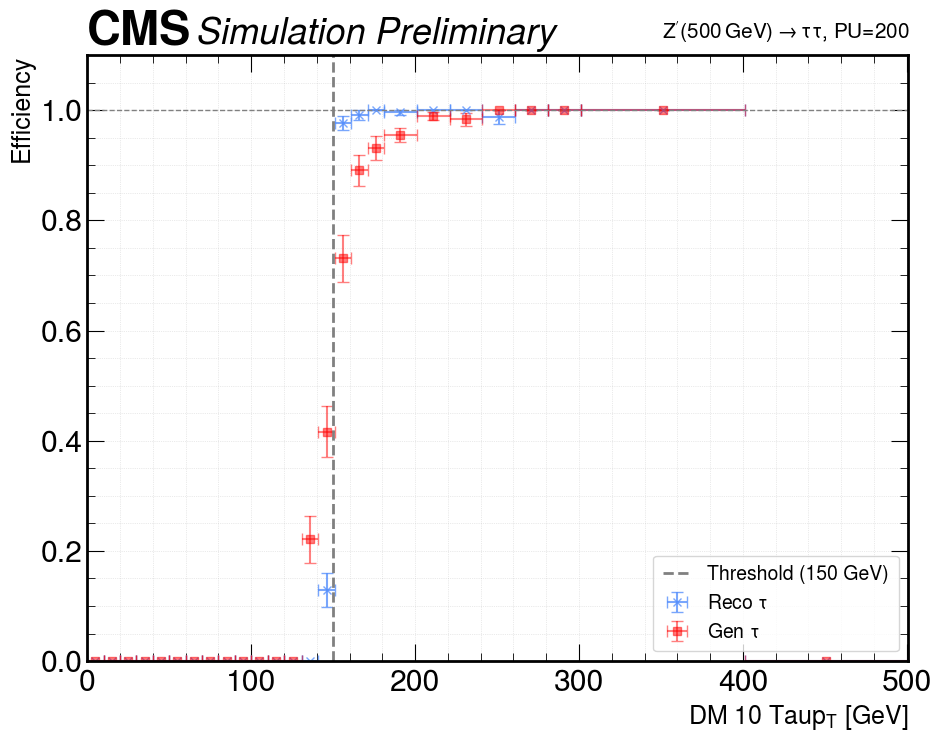

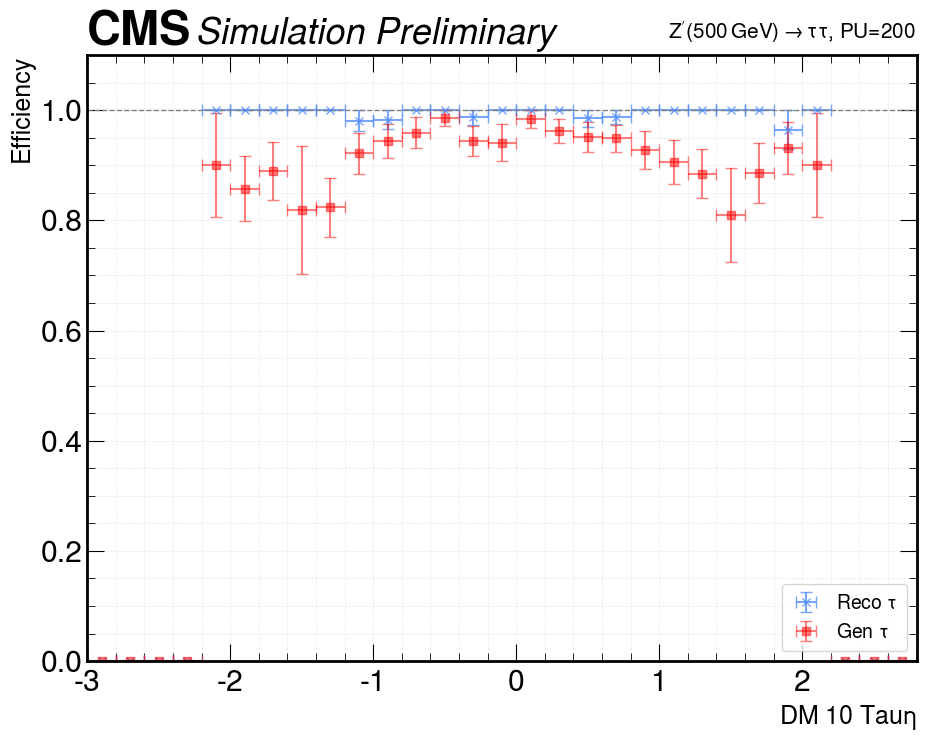

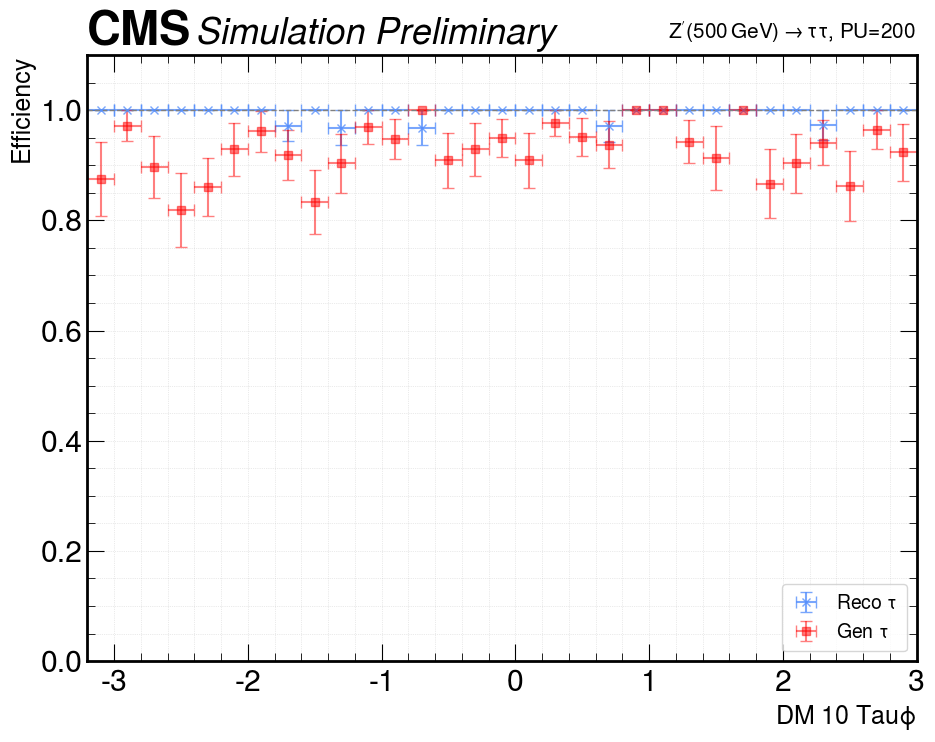

In [99]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
######################
## PT Plot
######################

bins_0 = np.arange(0, 130, 10)
bins_1 = np.arange(131, 180, 10)
bins_2 = np.arange(181, 300, 20)
bins_3 = np.arange(301, 601, 100)
bins_pt = np.concatenate((bins_0, bins_1, bins_2, bins_3))

counts_num_reco, edges_pt = np.histogram(num_pt_reco_150, bins=bins_pt)
counts_den_reco, _        = np.histogram(den_pt_reco_150, bins=bins_pt)
counts_num_gen,  _        = np.histogram(num_pt_gen_150,  bins=bins_pt)
counts_den_gen,  _        = np.histogram(den_pt_gen_150,  bins=bins_pt)
print(counts_num_gen)
print(counts_den_gen)
ratio_reco = np.divide(counts_num_reco, counts_den_reco,
                       out=np.zeros_like(counts_num_reco, dtype=float),
                       where=(counts_den_reco != 0))
ratio_gen  = np.divide(counts_num_gen,  counts_den_gen,
                       out=np.zeros_like(counts_num_gen,  dtype=float),
                       where=(counts_den_gen  != 0))

ratio_err_reco = np.where(counts_den_reco > 0,
                          np.sqrt(ratio_reco * (1 - ratio_reco) / np.maximum(counts_den_reco, 1)), 0)
ratio_err_gen  = np.where(counts_den_gen  > 0,
                          np.sqrt(ratio_gen  * (1 - ratio_gen)  / np.maximum(counts_den_gen,  1)), 0)

bin_centers_pt = (edges_pt[:-1] + edges_pt[1:]) / 2.0
half_widths_pt = (edges_pt[1:]  - edges_pt[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

ax.errorbar(bin_centers_pt, ratio_reco, xerr=half_widths_pt, yerr=ratio_err_reco,
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8, label=r'Reco $\tau$')
ax.errorbar(bin_centers_pt, ratio_gen,  xerr=half_widths_pt, yerr=ratio_err_gen,
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5, label=r'Gen $\tau$')

ax.set_xlabel(r'DM 10 Tau$p_T$ [GeV]', fontsize=18)
ax.set_ylabel('Efficiency', fontsize=18)
ax.set_xlim(edges_pt[0], edges_pt[-1])
ax.set_ylim(0, 1.1)
ax.axvline(x=150, color='gray', linestyle='--', linewidth=2, label='Threshold (150 GeV)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right', fontsize=14, frameon=True)
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)
hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
ax.text(0.7, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.tight_layout()
plt.show()

# pT > 150 GeV 구간 efficiency 출력
over_reco = (den_pt_reco_150 >= 150)
over_gen  = (den_pt_gen_150  >= 150)
#print(f"Reco tau efficiency (pT > 150 GeV): {num_pt_reco_150[num_pt_reco_150 >= 150].shape[0] / num_pt_reco_150[over_reco].shape[0] * 100:.1f}%")
#print(f"Gen  tau efficiency (pT > 150 GeV): {num_pt_gen_150[num_pt_gen_150 >= 150].shape[0]  / den_pt_gen_150[over_gen].shape[0]   * 100:.1f}%")


######################
## ETA Plot (pT > 150 GeV 이벤트만)
######################

bins_eta = np.arange(-3.0, 3.0, 0.2)

# pT > 150 컷 적용
num_eta_reco_cut = num_eta_reco_150[num_pt_reco_150 >= 150]
den_eta_reco_cut = den_eta_reco_150[den_pt_reco_150 >= 150]
num_eta_gen_cut  = num_eta_gen_150[ num_pt_gen_150  >= 150]
den_eta_gen_cut  = den_eta_gen_150[ den_pt_gen_150  >= 150]

counts_num_reco, edges_eta = np.histogram(num_eta_reco_cut, bins=bins_eta)
counts_den_reco, _         = np.histogram(den_eta_reco_cut, bins=bins_eta)
counts_num_gen,  _         = np.histogram(num_eta_gen_cut,  bins=bins_eta)
counts_den_gen,  _         = np.histogram(den_eta_gen_cut,  bins=bins_eta)

ratio_reco = np.divide(counts_num_reco, counts_den_reco,
                       out=np.zeros_like(counts_num_reco, dtype=float),
                       where=(counts_den_reco != 0))
ratio_gen  = np.divide(counts_num_gen,  counts_den_gen,
                       out=np.zeros_like(counts_num_gen,  dtype=float),
                       where=(counts_den_gen  != 0))

ratio_err_reco = np.where(counts_den_reco > 0,
                          np.sqrt(ratio_reco * (1 - ratio_reco) / np.maximum(counts_den_reco, 1)), 0)
ratio_err_gen  = np.where(counts_den_gen  > 0,
                          np.sqrt(ratio_gen  * (1 - ratio_gen)  / np.maximum(counts_den_gen,  1)), 0)

bin_centers_eta = (edges_eta[:-1] + edges_eta[1:]) / 2.0
half_widths_eta = (edges_eta[1:]  - edges_eta[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

ax.errorbar(bin_centers_eta, ratio_reco, xerr=half_widths_eta, yerr=ratio_err_reco,
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8, label=r'Reco $\tau$')
ax.errorbar(bin_centers_eta, ratio_gen,  xerr=half_widths_eta, yerr=ratio_err_gen,
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5, label=r'Gen $\tau$')

ax.set_xlabel(r'DM 10 Tau$\eta$', fontsize=18)
ax.set_ylabel('Efficiency', fontsize=18)
ax.set_xlim(edges_eta[0], edges_eta[-1])
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right', fontsize=14, frameon=True)
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)
hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
ax.text(0.7, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.tight_layout()
plt.show()


######################
## PHI Plot (pT > 150 GeV 이벤트만)
######################

bins_phi = np.arange(-3.2, 3.2, 0.2)

num_phi_reco_cut = num_phi_reco_150[num_pt_reco_150 >= 150]
den_phi_reco_cut = den_phi_reco_150[den_pt_reco_150 >= 150]
num_phi_gen_cut  = num_phi_gen_150[ num_pt_gen_150  >= 150]
den_phi_gen_cut  = den_phi_gen_150[ den_pt_gen_150  >= 150]

counts_num_reco, edges_phi = np.histogram(num_phi_reco_cut, bins=bins_phi)
counts_den_reco, _         = np.histogram(den_phi_reco_cut, bins=bins_phi)
counts_num_gen,  _         = np.histogram(num_phi_gen_cut,  bins=bins_phi)
counts_den_gen,  _         = np.histogram(den_phi_gen_cut,  bins=bins_phi)

ratio_reco = np.divide(counts_num_reco, counts_den_reco,
                       out=np.zeros_like(counts_num_reco, dtype=float),
                       where=(counts_den_reco != 0))
ratio_gen  = np.divide(counts_num_gen,  counts_den_gen,
                       out=np.zeros_like(counts_num_gen,  dtype=float),
                       where=(counts_den_gen  != 0))

ratio_err_reco = np.where(counts_den_reco > 0,
                          np.sqrt(ratio_reco * (1 - ratio_reco) / np.maximum(counts_den_reco, 1)), 0)
ratio_err_gen  = np.where(counts_den_gen  > 0,
                          np.sqrt(ratio_gen  * (1 - ratio_gen)  / np.maximum(counts_den_gen,  1)), 0)

bin_centers_phi = (edges_phi[:-1] + edges_phi[1:]) / 2.0
half_widths_phi = (edges_phi[1:]  - edges_phi[:-1]) / 2.0

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

ax.errorbar(bin_centers_phi, ratio_reco, xerr=half_widths_phi, yerr=ratio_err_reco,
            fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8, label=r'Reco $\tau$')
ax.errorbar(bin_centers_phi, ratio_gen,  xerr=half_widths_phi, yerr=ratio_err_gen,
            fmt='s', color='red', ecolor='red', capsize=4, alpha=0.5, label=r'Gen $\tau$')

ax.set_xlabel(r'DM 10 Tau$\phi$', fontsize=18)
ax.set_ylabel('Efficiency', fontsize=18)
ax.set_xlim(edges_phi[0], edges_phi[-1])
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
ax.legend(loc='lower right', fontsize=14, frameon=True)
ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)
hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
ax.text(0.7, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$, PU=200",
        transform=ax.transAxes, fontsize=15, va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.tight_layout()
plt.show()

=== HLT_LooseDeepTauPFTauHPS150 Efficiency (pT > 150 GeV) ===
Reco tau: 1011 / 1017 = 99.41 ± 0.24 %
Gen  tau: 951  / 1026  = 92.69  ± 0.81  %
+++++++++++++++++++++++++
[ 0  1 10 ...  5 11 11]
[10  0  1 ... 11 11 11]


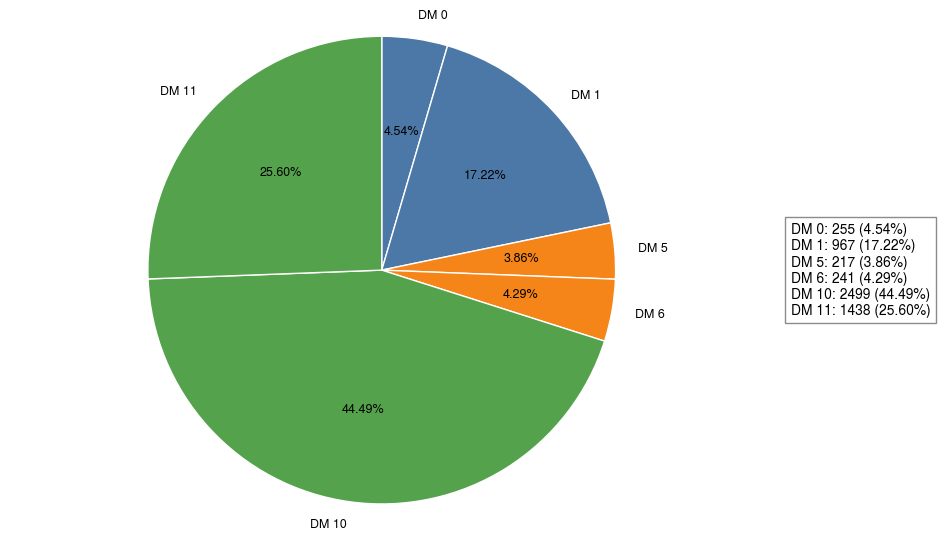

DM 0: 255 (4.54%)
DM 1: 967 (17.22%)
DM 5: 217 (3.86%)
DM 6: 241 (4.29%)
DM 10: 2499 (44.49%)
DM 11: 1438 (25.60%)


In [100]:
######################
## Efficiency 계산 (pT > 150 GeV)
######################

# Reco
over_num_reco = num_pt_reco_150[num_pt_reco_150 >= 150]
over_den_reco = den_pt_reco_150[den_pt_reco_150 >= 150]
eff_reco = len(over_num_reco) / len(over_den_reco) * 100

# Gen
over_num_gen = num_pt_gen_150[num_pt_gen_150 >= 150]
over_den_gen = den_pt_gen_150[den_pt_gen_150 >= 150]
eff_gen = len(over_num_gen) / len(over_den_gen) * 100

# 오차 (Binomial error)
n_num_reco = len(over_num_reco)
n_den_reco = len(over_den_reco)
err_reco = np.sqrt(eff_reco/100 * (1 - eff_reco/100) / n_den_reco) * 100

n_num_gen = len(over_num_gen)
n_den_gen = len(over_den_gen)
err_gen  = np.sqrt(eff_gen/100  * (1 - eff_gen/100)  / n_den_gen)  * 100

print(f"=== HLT_LooseDeepTauPFTauHPS150 Efficiency (pT > 150 GeV) ===")
print(f"Reco tau: {n_num_reco} / {n_den_reco} = {eff_reco:.2f} ± {err_reco:.2f} %")
print(f"Gen  tau: {n_num_gen}  / {n_den_gen}  = {eff_gen:.2f}  ± {err_gen:.2f}  %")
print("+++++++++++++++++++++++++")
print(num_hltHpsPFTau_decayMode)
print(den_hltHpsPFTau_decayMode)
# 원하는 순서로 정렬: 0,1,2 / 5,6 / 10,11
order = [0, 1, 2, 5, 6, 10, 11]
u, cts = np.unique(den_hltHpsPFTau_decayMode, return_counts=True)
count_map = dict(zip(u.tolist(), cts.tolist()))

modes = np.array(order, dtype=np.int32)
counts = np.array([count_map.get(m, 0) for m in order], dtype=int)

# 없는 mode(0 count) 제거
valid = counts > 0
modes = modes[valid]
counts = counts[valid]
percent = counts / counts.sum() * 100

# 그룹별 같은 색: [0,1,2], [5,6], [10,11]
group_color = {
    0: "#4C78A8", 1: "#4C78A8", 2: "#4C78A8",
    5: "#F58518", 6: "#F58518",
    10: "#54A24B", 11: "#54A24B"
}
colors = [group_color[int(m)] for m in modes]

fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(
    counts,
    labels=[f"DM {m}" for m in modes],
    colors=colors,
    autopct=lambda p: f"{p:.2f}%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 9}
)
ax.axis("equal")

# 플롯 안에 DM 통계 텍스트 추가
dm_text = "\n".join([f"DM {m}: {c} ({p:.2f}%)" for m, c, p in zip(modes, counts, percent)])
ax.text(
    1.05, 0.5, dm_text,
    transform=ax.transAxes,
    va="center", ha="left", fontsize=10,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

plt.tight_layout()
plt.show()

# 필요하면 콘솔에도 출력
for m, c, p in zip(modes, counts, percent):
    print(f"DM {m}: {c} ({p:.2f}%)")


In [1]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"

In [4]:
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()
for i in range(len(keys)):
    print(keys[i])

run
luminosityBlock
event
bunchCrossing
orbitNumber
hltPFPuppiHT_pt
hltPFPuppiMET_pt
nGenJet
GenJet_eta
GenJet_mass
GenJet_phi
GenJet_pt
nGenPart
GenPart_genPartIdxMother
GenPart_statusFlags
GenPart_pdgId
GenPart_status
GenPart_eta
GenPart_mass
GenPart_phi
GenPart_pt
nGenVisTau
GenVisTau_status
GenVisTau_charge
GenVisTau_genPartIdxMother
GenVisTau_eta
GenVisTau_mass
GenVisTau_phi
GenVisTau_pt
nhltElectron
hltElectron_missingHits
hltElectron_seedId
hltElectron_dEtaIn
hltElectron_dPhiIn
hltElectron_ecalIso
hltElectron_eta
hltElectron_hOverE
hltElectron_hcalIso
hltElectron_m
hltElectron_ooEMOop
hltElectron_phi
hltElectron_pt
hltElectron_r9
hltElectron_sMaj
hltElectron_sMin
hltElectron_sigmaIetaIeta
hltElectron_trackIso
nhltGeneralTrack
hltGeneralTrack_nPixelHits
hltGeneralTrack_nTrkLays
hltGeneralTrack_charge
hltGeneralTrack_chi2
hltGeneralTrack_dXY
hltGeneralTrack_dZ
hltGeneralTrack_eta
hltGeneralTrack_ndof
hltGeneralTrack_phi
hltGeneralTrack_pt
hltGeneralTrack_t0
hltGeneralTrack_vx
hltG

In [8]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()


## HLT 를 먼저 통과 한 이벤트 , hlthps tau 0개 이상인 이벤트만 -> 남은 이벤트 중에서 gen match -> genmatch 가 된 hlthps 의 이벤트를 남겨 놓음  



def get_info (sample):
    file = uproot.open(sample)
    events = file["Events"]
    runs = file["Runs"]
    keys = events.keys()

    # 변수 불러오기 

    tau_pt = events["hltHpsPFTau_pt"].array()
    tau_eta = events["hltHpsPFTau_eta"].array()
    tau_phi = events["hltHpsPFTau_phi"].array()
    tau_mass = events["hltHpsPFTau_mass"].array()

    hltHpsPFTau_decayMode = events["hltHpsPFTau_decayMode"].array()
    
    genvis_tau_pt = events["GenVisTau_pt"].array()
    genvis_tau_eta = events["GenVisTau_eta"].array()
    genvis_tau_phi = events["GenVisTau_phi"].array()
    genvis_tau_mass = events["GenVisTau_mass"].array()
    
    #print(len(genvis_tau_pt),"gen vis tau total events")

    # 필터 설정
    gen_obj_mask = (genvis_tau_pt > 130) & (abs(genvis_tau_eta) < 2.1)
    reco_obj_mask = (tau_pt > 130) & (abs(tau_eta) < 2.1)
    
    genvis_tau_pt   = genvis_tau_pt[gen_obj_mask]
    genvis_tau_eta  = genvis_tau_eta[gen_obj_mask]
    genvis_tau_phi  = genvis_tau_phi[gen_obj_mask]

    tau_pt   = tau_pt[reco_obj_mask]
    tau_eta  = tau_eta[reco_obj_mask]
    tau_phi  = tau_phi[reco_obj_mask]
    ## trigger filter ( returns_num_den 에서 사용됨  )
    tau_trigger_filter = events["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"].array()

    ## hlthpstau 1개 이상 필터 

    tau_num = ak.num(tau_pt)
    no_tau = (tau_num == 0) # [ False, True, False, ... ] 2000개 
    has_tau = ~no_tau

    gen_vis_tau_num = ak.num(genvis_tau_pt)
    no_gen_vis_tau = (gen_vis_tau_num == 0)
    has_gen_vis_tau = ~no_gen_vis_tau   
    hlt_has_tau_filter = (has_tau)&(has_gen_vis_tau) ## hlthps tau 1개 이상 있는 이벤트만 선택

    tau_triggerd_list = hlt_has_tau_filter 

    ## final selected variables ( hlthps 있는 이벤트만 남김 )
    final_tau_pt = tau_pt[tau_triggerd_list]
    final_tau_eta = tau_eta[tau_triggerd_list]
    final_tau_phi = tau_phi[tau_triggerd_list]
    final_tau_mass = tau_mass[tau_triggerd_list]

    final_genvis_tau_pt = genvis_tau_pt[tau_triggerd_list]
    final_genvis_tau_eta = genvis_tau_eta[tau_triggerd_list]
    final_genvis_tau_phi = genvis_tau_phi[tau_triggerd_list]
    final_genvis_tau_mass = genvis_tau_mass[tau_triggerd_list]

    tau_trigger_filtered = tau_trigger_filter[tau_triggerd_list]

    hltHpsPFTau_decayMode = hltHpsPFTau_decayMode[tau_triggerd_list]


    total_events = len(tau_pt)
    print("total events:", total_events,"->","after trigger filter:",ak.sum(has_tau),"->","after reconstructed hlthps ,events remain",len(final_tau_pt))
    return events,final_tau_pt, final_tau_eta, final_tau_phi, final_tau_mass, final_genvis_tau_pt, final_genvis_tau_eta, final_genvis_tau_phi, final_genvis_tau_mass ,genvis_tau_pt , genvis_tau_eta , genvis_tau_phi ,tau_trigger_filtered , hltHpsPFTau_decayMode


def gen_match(tau_pt, tau_eta, tau_phi, genvis_tau_pt, genvis_tau_eta, genvis_tau_phi, deltaR_threshold=0.1):
    """
    Leading reco tau 기준으로 gen tau와 매칭.
    후보가 여럿이면 deltaR이 가장 작은 gen tau 선택.
    반환: events_flag (bool list), matched_gen_pt/eta/phi (매칭된 gen tau의 운동학 정보)
    """
    events_flag      = []
    matched_gen_pt   = []
    matched_gen_eta  = []
    matched_gen_phi  = []

    for i in range(len(tau_pt)):

        # Leading reco tau 찾기 (pT 기준 정렬 후 index 0)
        if len(tau_pt[i]) == 0:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)
            continue

        reco_indices  = ak.argsort(tau_pt[i], ascending=False)
        lead_pt   = tau_pt[i][reco_indices[0]]
        lead_eta  = tau_eta[i][reco_indices[0]]
        lead_phi  = tau_phi[i][reco_indices[0]]

        # eta 2.1 컷
        if abs(lead_eta) > 2.1:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)
            continue

        # Leading reco tau와 모든 gen tau 매칭 시도
        best_dR   = 999.
        best_gen_idx = -1

        for j in range(len(genvis_tau_pt[i])):
            g_pt  = genvis_tau_pt[i][j]
            g_eta = genvis_tau_eta[i][j]
            g_phi = genvis_tau_phi[i][j]

            dR  = deltaR(lead_eta, lead_phi, g_eta, g_phi)
            dpt = abs(float(lead_pt) - float(g_pt))

            if dR < deltaR_threshold : #and dpt < delta_pt_threshold:
                if dR < best_dR:          # deltaR 가장 작은 gen 선택
                    best_dR      = dR
                    best_gen_idx = j

        if best_gen_idx >= 0:
            events_flag.append(True)
            matched_gen_pt.append(float(genvis_tau_pt[i][best_gen_idx]))
            matched_gen_eta.append(float(genvis_tau_eta[i][best_gen_idx]))
            matched_gen_phi.append(float(genvis_tau_phi[i][best_gen_idx]))
        else:
            events_flag.append(False)
            matched_gen_pt.append(np.nan)
            matched_gen_eta.append(np.nan)
            matched_gen_phi.append(np.nan)

    return events_flag, matched_gen_pt, matched_gen_eta, matched_gen_phi

def returns_num_den(events_flag, matched_gen_pt, matched_gen_eta, matched_gen_phi,
                    final_tau_pt, final_tau_eta, final_tau_phi,
                    tau_trigger_filter, hltHpsPFTau_decayMode):

    events_flag_arr    = np.array(events_flag, dtype=bool)
    matched_gen_pt_arr = np.array(matched_gen_pt)
    matched_gen_eta_arr= np.array(matched_gen_eta)
    matched_gen_phi_arr= np.array(matched_gen_phi)
    tau_trigger_arr    = np.array(tau_trigger_filter, dtype=bool)

    # ── Den: gen-match 성공한 이벤트 (gen tau 기준) ──
    den_mask = events_flag_arr        
    den_mask = np.ones_like(den_mask, dtype=bool)                # gen-match 된 이벤트만
    num_mask = events_flag_arr & tau_trigger_arr      # gen-match + HLT passed

    # ── Gen 분모/분자 (gen tau pt 기준) ──
    den_pt_gen  = matched_gen_pt_arr[den_mask]
    den_eta_gen = matched_gen_eta_arr[den_mask]
    den_phi_gen = matched_gen_phi_arr[den_mask]

    num_pt_gen  = matched_gen_pt_arr[num_mask]
    num_eta_gen = matched_gen_eta_arr[num_mask]
    num_phi_gen = matched_gen_phi_arr[num_mask]

    # ── Reco leading tau 추출 헬퍼 ──
    def extract_leading_kinematic(pt_arr, kin_arr, mask):
        pt_sel  = pt_arr[mask]
        kin_sel = kin_arr[mask]
        sorted_idx = ak.argsort(pt_sel, axis=1, ascending=False)
        return ak.to_numpy(ak.flatten(kin_sel[sorted_idx[:, :1]], axis=1))

    # ── Reco 분모/분자 ──
    den_pt_reco  = extract_leading_kinematic(final_tau_pt, final_tau_pt,  den_mask)
    num_pt_reco  = extract_leading_kinematic(final_tau_pt, final_tau_pt,  num_mask)
    den_eta_reco = extract_leading_kinematic(final_tau_pt, final_tau_eta, den_mask)
    num_eta_reco = extract_leading_kinematic(final_tau_pt, final_tau_eta, num_mask)
    den_phi_reco = extract_leading_kinematic(final_tau_pt, final_tau_phi, den_mask)
    num_phi_reco = extract_leading_kinematic(final_tau_pt, final_tau_phi, num_mask)

    den_hltHpsPFTau_decayMode = extract_leading_kinematic(final_tau_pt, hltHpsPFTau_decayMode, den_mask)
    num_hltHpsPFTau_decayMode = extract_leading_kinematic(final_tau_pt, hltHpsPFTau_decayMode, num_mask)



    print(f"Den (gen matched):          {den_mask.sum()}")
    print(f"Num (matched + triggered):  {num_mask.sum()}")

# 기존
    return (num_pt_gen, den_pt_gen, num_eta_gen, den_eta_gen, num_phi_gen, den_phi_gen,
        num_pt_reco, den_pt_reco, num_eta_reco, den_eta_reco, num_phi_reco, den_phi_reco,
        num_hltHpsPFTau_decayMode, den_hltHpsPFTau_decayMode)
def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)

sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
events_150,final_tau_pt_150, final_tau_eta_150, final_tau_phi_150, final_tau_mass_150, final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150, final_genvis_tau_mass_150,genvis_tau_pt_150 , genvis_tau_eta_150, genvis_tau_phi_150,tau_trigger_filter_150 , hltHpsPFTau_decayMode = get_info(sample)
# ── 호출부 ──
events_flag_150, matched_gen_pt_150, matched_gen_eta_150, matched_gen_phi_150 = gen_match(
    final_tau_pt_150, final_tau_eta_150, final_tau_phi_150,
    final_genvis_tau_pt_150, final_genvis_tau_eta_150, final_genvis_tau_phi_150
)

(num_pt_gen_150, den_pt_gen_150,
 num_eta_gen_150, den_eta_gen_150,
 num_phi_gen_150, den_phi_gen_150,
 num_pt_reco_150, den_pt_reco_150,
 num_eta_reco_150, den_eta_reco_150,
 num_phi_reco_150, den_phi_reco_150,
 num_hltHpsPFTau_decayMode, den_hltHpsPFTau_decayMode) = returns_num_den(
    events_flag_150, matched_gen_pt_150, matched_gen_eta_150, matched_gen_phi_150,
    final_tau_pt_150, final_tau_eta_150, final_tau_phi_150,
    tau_trigger_filter_150,hltHpsPFTau_decayMode
)

import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import awkward as ak

# ──────────────────────────────────────────────
# Decay mode 그룹 정의
# ──────────────────────────────────────────────
DM_GROUPS = {
    "all":         {"modes": [0,1,2,5,6,10,11], "label": r"$\tau$",       "color": "#7B2D8B"},
    "1Prong_DM0":  {"modes": [0],     "label": r"1-Prong DM0",  "color": "#4C78A8"},
    "1Prong_DM1":  {"modes": [1],     "label": r"1-Prong DM1",  "color": "#9ECAE9"},
    "1Prong_DM2":  {"modes": [2],     "label": r"1-Prong DM2",  "color": "#3182BD"},
    "2Prong_DM5":  {"modes": [5],     "label": r"2-Prong DM5",  "color": "#F58518"},
    "2Prong_DM6":  {"modes": [6],     "label": r"2-Prong DM6",  "color": "#FFBF79"},
    "3Prong_DM10": {"modes": [10],    "label": r"3-Prong DM10", "color": "#54A24B"},
    "3Prong_DM11": {"modes": [11],    "label": r"3-Prong DM11", "color": "#88D27A"},
    # 프롱별 합산
    "1Prong_all":  {"modes": [0,1,2], "label": r"1-Prong (all)","color": "#4C78A8"},
    "2Prong_all":  {"modes": [5,6],   "label": r"2-Prong (all)","color": "#F58518"},
    "3Prong_all":  {"modes": [10,11], "label": r"3-Prong (all)","color": "#54A24B"},
}

# ──────────────────────────────────────────────
# Bin 설정
# ──────────────────────────────────────────────
bins_0  = np.arange(0,   130, 10)
bins_1  = np.arange(131, 180, 10)
bins_2  = np.arange(181, 300, 20)
bins_3  = np.arange(301, 601, 100)
BINS_PT  = np.concatenate((bins_0, bins_1, bins_2, bins_3))
BINS_ETA = np.arange(-3.0, 3.2, 0.2)
BINS_PHI = np.arange(-3.2, 3.4, 0.2)

PT_CUT = 150   # plateau efficiency 계산 기준


def make_dm_mask(dm_arr, modes):
    mask = np.zeros(len(dm_arr), dtype=bool)
    for m in modes:
        mask |= (dm_arr == m)
    return mask


def ratio_and_err(num_counts, den_counts):
    ratio = np.divide(num_counts, den_counts,
                      out=np.zeros_like(num_counts, dtype=float),
                      where=(den_counts != 0))
    err   = np.where(den_counts > 0,
                     np.sqrt(ratio * (1 - ratio) / np.maximum(den_counts, 1)), 0)
    return ratio, err


def plot_efficiency(ax, bin_centers, half_widths, ratio_reco, err_reco,
                    ratio_gen, err_gen, xlabel, xlim, label_suffix=""):
    ax.errorbar(bin_centers, ratio_reco, xerr=half_widths, yerr=err_reco,
                fmt='x', color='C0', ecolor='C0', capsize=4, alpha=0.8,
                label=r'Reco $\tau$' + label_suffix)
    ax.errorbar(bin_centers, ratio_gen,  xerr=half_widths, yerr=err_gen,
                fmt='s', color='red',  ecolor='red',  capsize=4, alpha=0.5,
                label=r'Gen $\tau$'  + label_suffix)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel('Efficiency', fontsize=16)
    ax.set_xlim(*xlim)
    ax.set_ylim(0, 1.15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1)
    ax.legend(loc='lower right', fontsize=12, frameon=True)
    ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)


def run_all(
    num_pt_reco, den_pt_reco, num_eta_reco, den_eta_reco, num_phi_reco, den_phi_reco,
    num_pt_gen,  den_pt_gen,  num_eta_gen,  den_eta_gen,  num_phi_gen,  den_phi_gen,
    num_dm_arr,  den_dm_arr,
    sample_label="Z'(500 GeV) → ττ, PU=200",
    pt_cut=PT_CUT,
    save_dir=None
):
    """
    모든 DM 그룹에 대해 pT / eta / phi efficiency 플롯 + plateau efficiency 출력.

    Parameters
    ----------
    num_*/den_* : np.ndarray   returns_num_den 의 출력 (decay mode 필터 없는 버전)
    num_dm_arr / den_dm_arr    : decay mode 배열 (num/den 각각)
    sample_label               : 플롯 우상단 텍스트
    pt_cut                     : plateau efficiency 계산 pT 기준
    save_dir                   : None 이면 plt.show(), 경로 주면 파일 저장
    """

    plt.style.use(hep.style.CMS)
    results = {}   # {group_key: {"eff_reco": .., "err_reco": .., "eff_gen": .., "err_gen": ..}}

    for key, info in DM_GROUPS.items():
        modes = info["modes"]
        label = info["label"]

        # ── decay mode mask ──
        num_mask = make_dm_mask(num_dm_arr, modes)
        den_mask = make_dm_mask(den_dm_arr, modes)

        # ── 필터된 배열 ──
        _num_pt_reco  = num_pt_reco[num_mask];  _den_pt_reco  = den_pt_reco[den_mask]
        _num_eta_reco = num_eta_reco[num_mask];  _den_eta_reco = den_eta_reco[den_mask]
        _num_phi_reco = num_phi_reco[num_mask];  _den_phi_reco = den_phi_reco[den_mask]
        _num_pt_gen   = num_pt_gen[num_mask];    _den_pt_gen   = den_pt_gen[den_mask]
        _num_eta_gen  = num_eta_gen[num_mask];   _den_eta_gen  = den_eta_gen[den_mask]
        _num_phi_gen  = num_phi_gen[num_mask];   _den_phi_gen  = den_phi_gen[den_mask]

        if den_mask.sum() == 0:
            print(f"[{label}] 이벤트 없음, 스킵")
            continue

        # ══════════════════════════════
        # 1) pT efficiency
        # ══════════════════════════════
        c_num_reco, edges = np.histogram(_num_pt_reco, bins=BINS_PT)
        c_den_reco, _     = np.histogram(_den_pt_reco, bins=BINS_PT)
        c_num_gen,  _     = np.histogram(_num_pt_gen,  bins=BINS_PT)
        c_den_gen,  _     = np.histogram(_den_pt_gen,  bins=BINS_PT)

        r_reco, e_reco = ratio_and_err(c_num_reco, c_den_reco)
        r_gen,  e_gen  = ratio_and_err(c_num_gen,  c_den_gen)
        bc = (edges[:-1] + edges[1:]) / 2
        hw = (edges[1:]  - edges[:-1]) / 2

        fig, ax = plt.subplots(figsize=(10, 7))
        plot_efficiency(ax, bc, hw, r_reco, e_reco, r_gen, e_gen,
                        rf'{label} $p_T$ [GeV]',
                        (edges[0], edges[-1]))
        ax.axvline(x=pt_cut, color='gray', linestyle='--', linewidth=2,
                   label=f'Threshold ({pt_cut} GeV)')
        ax.legend(loc='lower right', fontsize=12)
        hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
        ax.text(0.75, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$" + ", PU=200",
                transform=ax.transAxes, fontsize=13, va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        #ax.set_title(f"{label} — pT Efficiency", fontsize=14, pad=14)
        plt.tight_layout()
        _save_or_show(fig, save_dir, f"{key}_pt_eff.png")

        # ══════════════════════════════
        # 2) eta efficiency (pT > pt_cut)
        # ══════════════════════════════
        num_eta_reco_cut = _num_eta_reco[_num_pt_reco >= pt_cut]
        den_eta_reco_cut = _den_eta_reco[_den_pt_reco >= pt_cut]
        num_eta_gen_cut  = _num_eta_gen[ _num_pt_gen  >= pt_cut]
        den_eta_gen_cut  = _den_eta_gen[ _den_pt_gen  >= pt_cut]

        c_num_reco, edges = np.histogram(num_eta_reco_cut, bins=BINS_ETA)
        c_den_reco, _     = np.histogram(den_eta_reco_cut, bins=BINS_ETA)
        c_num_gen,  _     = np.histogram(num_eta_gen_cut,  bins=BINS_ETA)
        c_den_gen,  _     = np.histogram(den_eta_gen_cut,  bins=BINS_ETA)

        r_reco, e_reco = ratio_and_err(c_num_reco, c_den_reco)
        r_gen,  e_gen  = ratio_and_err(c_num_gen,  c_den_gen)
        bc = (edges[:-1] + edges[1:]) / 2
        hw = (edges[1:]  - edges[:-1]) / 2

        fig, ax = plt.subplots(figsize=(10, 7))
        plot_efficiency(ax, bc, hw, r_reco, e_reco, r_gen, e_gen,
                        rf'{label} $\eta$  ($p_T > {pt_cut}$ GeV)',
                        (edges[0], edges[-1]))
        hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
        ax.text(0.75, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$" + ", PU=200",
                transform=ax.transAxes, fontsize=13, va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        #ax.set_title(f"{label} — η Efficiency (pT > {pt_cut} GeV)", fontsize=14, pad=14)
        plt.tight_layout()
        _save_or_show(fig, save_dir, f"{key}_eta_eff.png")

        # ══════════════════════════════
        # 3) phi efficiency (pT > pt_cut)
        # ══════════════════════════════
        num_phi_reco_cut = _num_phi_reco[_num_pt_reco >= pt_cut]
        den_phi_reco_cut = _den_phi_reco[_den_pt_reco >= pt_cut]
        num_phi_gen_cut  = _num_phi_gen[ _num_pt_gen  >= pt_cut]
        den_phi_gen_cut  = _den_phi_gen[ _den_pt_gen  >= pt_cut]

        c_num_reco, edges = np.histogram(num_phi_reco_cut, bins=BINS_PHI)
        c_den_reco, _     = np.histogram(den_phi_reco_cut, bins=BINS_PHI)
        c_num_gen,  _     = np.histogram(num_phi_gen_cut,  bins=BINS_PHI)
        c_den_gen,  _     = np.histogram(den_phi_gen_cut,  bins=BINS_PHI)

        r_reco, e_reco = ratio_and_err(c_num_reco, c_den_reco)
        r_gen,  e_gen  = ratio_and_err(c_num_gen,  c_den_gen)
        bc = (edges[:-1] + edges[1:]) / 2
        hw = (edges[1:]  - edges[:-1]) / 2

        fig, ax = plt.subplots(figsize=(10, 7))
        plot_efficiency(ax, bc, hw, r_reco, e_reco, r_gen, e_gen,
                        rf'{label} $\phi$  ($p_T > {pt_cut}$ GeV)',
                        (edges[0], edges[-1]))
        hep.cms.text("Simulation Preliminary", loc=0, ax=ax)
        ax.text(0.75, 1.06, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$" + ", PU=200",
                transform=ax.transAxes, fontsize=13, va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        #ax.set_title(f"{label} — φ Efficiency (pT > {pt_cut} GeV)", fontsize=14, pad=14)
        plt.tight_layout()
        _save_or_show(fig, save_dir, f"{key}_phi_eff.png")

        # ══════════════════════════════
        # 4) Plateau efficiency (pT > pt_cut)
        # ══════════════════════════════
        n_num_reco = (_num_pt_reco >= pt_cut).sum()
        n_den_reco = (_den_pt_reco >= pt_cut).sum()
        n_num_gen  = (_num_pt_gen  >= pt_cut).sum()
        n_den_gen  = (_den_pt_gen  >= pt_cut).sum()

        eff_reco = n_num_reco / n_den_reco * 100 if n_den_reco > 0 else 0.
        eff_gen  = n_num_gen  / n_den_gen  * 100 if n_den_gen  > 0 else 0.
        err_reco = np.sqrt(eff_reco/100 * (1-eff_reco/100) / max(n_den_reco,1)) * 100
        err_gen  = np.sqrt(eff_gen /100 * (1-eff_gen /100) / max(n_den_gen, 1)) * 100

        results[key] = dict(label=label,
                            n_num_reco=n_num_reco, n_den_reco=n_den_reco,
                            eff_reco=eff_reco, err_reco=err_reco,
                            n_num_gen=n_num_gen,  n_den_gen=n_den_gen,
                            eff_gen=eff_gen,   err_gen=err_gen)

    # ══════════════════════════════
    # 5) 요약 출력
    # ══════════════════════════════
    print(f"\n{'='*65}")
    print(f"  Plateau Efficiency (pT > {pt_cut} GeV) — 전체 요약")
    print(f"{'='*65}")
    print(f"{'Group':<18} {'Reco (num/den)':<22} {'Reco Eff':<18} {'Gen Eff'}")
    print(f"{'-'*65}")
    for key, r in results.items():
        print(f"{r['label']:<18} {r['n_num_reco']:>5}/{r['n_den_reco']:<14} "
              f"{r['eff_reco']:>6.2f} ± {r['err_reco']:>5.2f} %    "
              f"{r['eff_gen']:>6.2f} ± {r['err_gen']:>5.2f} %")
    print(f"{'='*65}\n")

    return results


def _save_or_show(fig, save_dir, filename):
    if save_dir:
        import os
        fig.savefig(os.path.join(save_dir, filename), dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  saved → {filename}")
    else:
        plt.show()
        plt.close(fig)

import os
os.makedirs("./plots", exist_ok=True)
# returns_num_den 에서 decay mode 필터를 제거한 버전으로 먼저 실행한 뒤:
# 
results = run_all(
num_pt_reco_150, den_pt_reco_150,
num_eta_reco_150, den_eta_reco_150,
num_phi_reco_150, den_phi_reco_150,
num_pt_gen_150,  den_pt_gen_150,
num_eta_gen_150, den_eta_gen_150,
num_phi_gen_150, den_phi_gen_150,
num_hltHpsPFTau_decayMode, den_hltHpsPFTau_decayMode,
sample_label=r"Z'(500\,\mathrm{GeV}) \to \tau\tau,\ \mathrm{PU=200}",
pt_cut=150,save_dir="./plots"   # None 이면 plt.show()
)

total events: 20000 -> after trigger filter: 7307 -> after reconstructed hlthps ,events remain 5989
Den (gen matched):          5989
Num (matched + triggered):  4537
  saved → all_pt_eff.png
  saved → all_eta_eff.png
  saved → all_phi_eff.png
  saved → 1Prong_DM0_pt_eff.png
  saved → 1Prong_DM0_eta_eff.png
  saved → 1Prong_DM0_phi_eff.png
  saved → 1Prong_DM1_pt_eff.png
  saved → 1Prong_DM1_eta_eff.png
  saved → 1Prong_DM1_phi_eff.png
[1-Prong DM2] 이벤트 없음, 스킵
  saved → 2Prong_DM5_pt_eff.png
  saved → 2Prong_DM5_eta_eff.png
  saved → 2Prong_DM5_phi_eff.png
  saved → 2Prong_DM6_pt_eff.png
  saved → 2Prong_DM6_eta_eff.png
  saved → 2Prong_DM6_phi_eff.png
  saved → 3Prong_DM10_pt_eff.png
  saved → 3Prong_DM10_eta_eff.png
  saved → 3Prong_DM10_phi_eff.png
  saved → 3Prong_DM11_pt_eff.png
  saved → 3Prong_DM11_eta_eff.png
  saved → 3Prong_DM11_phi_eff.png
  saved → 1Prong_all_pt_eff.png
  saved → 1Prong_all_eta_eff.png
  saved → 1Prong_all_phi_eff.png
  saved → 2Prong_all_pt_eff.png
  saved 